In [1]:
import xarray as xr
import numpy as np

glorys = xr.open_dataset("glorys_train.nc")
sst = xr.open_dataset("sst_train.nc")
ssh = xr.open_dataset("ssh_train.nc")
sss = xr.open_dataset("sss_train.nc")

print("GLORYS:", glorys.dims)
print("SST:", sst.dims)
print("SSH:", ssh.dims)
print("SSS:", sss.dims)

GLORYS: FrozenMappingWarningOnValuesAccess({'time': 182, 'depth': 35, 'latitude': 241, 'longitude': 241})
SST: FrozenMappingWarningOnValuesAccess({'time': 182, 'latitude': 400, 'longitude': 400})
SSH: FrozenMappingWarningOnValuesAccess({'time': 182, 'latitude': 160, 'longitude': 160})
SSS: FrozenMappingWarningOnValuesAccess({'time': 26, 'latitude': 100, 'longitude': 78})


In [2]:
# Define target grid: 0.25° resolution over your region
target_lat = np.arange(5, 25.25, 0.25)
target_lon = np.arange(80, 100.25, 0.25)

print(f"Target grid: {len(target_lat)} lat x {len(target_lon)} lon points")

# Regrid SST, SSH, SSS onto target grid using linear interpolation
sst_regridded = sst.interp(latitude=target_lat, longitude=target_lon, method="linear")
ssh_regridded = ssh.interp(latitude=target_lat, longitude=target_lon, method="linear")
sss_regridded = sss.interp(latitude=target_lat, longitude=target_lon, method="linear")

print("SST regridded:", sst_regridded.dims)
print("SSH regridded:", ssh_regridded.dims)
print("SSS regridded:", sss_regridded.dims)

Target grid: 81 lat x 81 lon points
SST regridded: FrozenMappingWarningOnValuesAccess({'time': 182, 'latitude': 81, 'longitude': 81})
SSH regridded: FrozenMappingWarningOnValuesAccess({'time': 182, 'latitude': 81, 'longitude': 81})
SSS regridded: FrozenMappingWarningOnValuesAccess({'time': 26, 'latitude': 81, 'longitude': 81})


In [3]:
standard_depths = [0, 5, 10, 20, 30, 50, 75, 100, 125, 150, 200, 300, 500, 700, 1000]

glorys_regridded = glorys.interp(
    latitude=target_lat, 
    longitude=target_lon, 
    depth=standard_depths, 
    method="linear"
)

print("GLORYS regridded:", glorys_regridded.dims)

GLORYS regridded: FrozenMappingWarningOnValuesAccess({'time': 182, 'depth': 15, 'latitude': 81, 'longitude': 81})


In [4]:
print(glorys_regridded.depth.values)
print(glorys_regridded.thetao.isel(time=0).sel(depth=1000).values[:5, :5])  # check for NaNs

[   0    5   10   20   30   50   75  100  125  150  200  300  500  700
 1000]
[[nan nan nan nan nan]
 [nan nan nan nan nan]
 [nan nan nan nan nan]
 [nan nan nan nan nan]
 [nan nan nan nan nan]]


In [5]:
sss_daily = sss_regridded.reindex(time=sst_regridded.time, method="ffill")
print("SSS daily:", sss_daily.dims)

SSS daily: FrozenMappingWarningOnValuesAccess({'time': 182, 'latitude': 81, 'longitude': 81})


In [6]:
combined = xr.Dataset({
    "sst": sst_regridded["analysed_sst"],
    "ssh": ssh_regridded["sla"],
    "sss": sss_daily["sss"],
    "temperature": glorys_regridded["thetao"],  # target
})
print(combined)

<xarray.Dataset> Size: 172MB
Dimensions:      (time: 182, latitude: 81, longitude: 81, depth: 15)
Coordinates:
  * time         (time) datetime64[ns] 1kB 2020-01-01 2020-01-02 ... 2020-06-30
  * latitude     (latitude) float64 648B 5.0 5.25 5.5 5.75 ... 24.5 24.75 25.0
  * longitude    (longitude) float64 648B 80.0 80.25 80.5 ... 99.5 99.75 100.0
  * depth        (depth) int64 120B 0 5 10 20 30 50 ... 150 200 300 500 700 1000
Data variables:
    sst          (time, latitude, longitude) float64 10MB nan nan ... nan nan
    ssh          (time, latitude, longitude) float64 10MB nan nan ... nan nan
    sss          (time, latitude, longitude) float64 10MB nan nan ... nan nan
    temperature  (time, depth, latitude, longitude) float64 143MB nan ... nan


In [7]:
print(combined.sst.isel(time=0, latitude=40, longitude=40).values)
print(combined.ssh.isel(time=0, latitude=40, longitude=40).values)
print(combined.sss.isel(time=0, latitude=40, longitude=40).values)
print(combined.temperature.isel(time=0, depth=0, latitude=40, longitude=40).values)

300.9649932747707
0.016725
nan
nan


In [8]:
print(sss_regridded.sss.isel(time=0).values)  # print the whole grid, see how much is NaN

[[        nan         nan         nan ...         nan         nan
          nan]
 [        nan 33.29519056 33.3606602  ... 32.44321752 31.93810645
          nan]
 [        nan 32.98780644 33.12600364 ... 32.19614868 31.71348163
          nan]
 ...
 [        nan         nan         nan ...         nan         nan
          nan]
 [        nan         nan         nan ...         nan         nan
          nan]
 [        nan         nan         nan ...         nan         nan
          nan]]


In [9]:
print(sss.sss.isel(time=0).min().values, sss.sss.isel(time=0).max().values)  # check original file has real data at all

25.65981427062685 34.199628958846176


In [10]:
# Shrink target grid by a small margin to stay inside all sources
target_lat = np.arange(5.5, 24.5, 0.25)
target_lon = np.arange(80.5, 99.5, 0.25)

print(f"New target grid: {len(target_lat)} lat x {len(target_lon)} lon points")

New target grid: 76 lat x 76 lon points


In [11]:
standard_depths = [0.5, 5, 10, 20, 30, 50, 75, 100, 125, 150, 200, 300, 500, 700]  # 0.5 instead of 0, dropped 1000

sst_regridded = sst.interp(latitude=target_lat, longitude=target_lon, method="linear")
ssh_regridded = ssh.interp(latitude=target_lat, longitude=target_lon, method="linear")
sss_regridded = sss.interp(latitude=target_lat, longitude=target_lon, method="linear")
glorys_regridded = glorys.interp(latitude=target_lat, longitude=target_lon, depth=standard_depths, method="linear")

sss_daily = sss_regridded.reindex(time=sst_regridded.time, method="ffill")

combined = xr.Dataset({
    "sst": sst_regridded["analysed_sst"],
    "ssh": ssh_regridded["sla"],
    "sss": sss_daily["sss"],
    "temperature": glorys_regridded["thetao"],
})

# Verify no NaNs this time
print("NaN counts:")
print("SST:", combined.sst.isnull().sum().values)
print("SSH:", combined.ssh.isnull().sum().values)
print("SSS:", combined.sss.isnull().sum().values)
print("Temperature:", combined.temperature.isnull().sum().values)

NaN counts:
SST: 346528
SSH: 338702
SSS: 450482
Temperature: 6089538


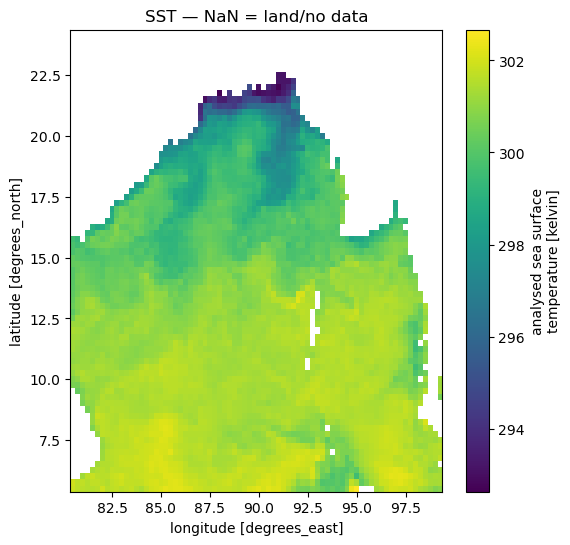

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
combined.sst.isel(time=0).plot()
plt.title("SST — NaN = land/no data")
plt.show()

In [13]:
# Create ocean mask from SST (True where ocean, False where land/no data)
ocean_mask = combined.sst.isel(time=0).notnull()
print(f"Ocean pixels: {ocean_mask.sum().values} out of {ocean_mask.size}")

Ocean pixels: 3872 out of 5776


In [14]:
combined_masked = combined.where(ocean_mask)
print("After masking:")
print("SST NaN:", combined_masked.sst.isnull().sum().values)
print("Temperature NaN:", combined_masked.temperature.isnull().sum().values)

After masking:
SST NaN: 346528
Temperature NaN: 6101004


In [15]:
import numpy as np

# Inputs: (time, lat, lon, channels=3)
X = np.stack([
    combined_masked.sst.values,
    combined_masked.ssh.values,
    combined_masked.sss.values
], axis=-1)

# Target: (time, lat, lon, depth=14)
y = np.transpose(combined_masked.temperature.values, (0, 2, 3, 1))  # reorder to (time, lat, lon, depth)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (182, 76, 76, 3)
y shape: (182, 76, 76, 14)


In [16]:
split_idx = int(0.8 * X.shape[0])  # 80% train, 20% val, chronological

X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)

Train: (145, 76, 76, 3) (145, 76, 76, 14)
Val: (37, 76, 76, 3) (37, 76, 76, 14)


In [17]:
# Save processed arrays so you don't have to redo preprocessing every time
np.save("X_train.npy", X_train)
np.save("X_val.npy", X_val)
np.save("y_train.npy", y_train)
np.save("y_val.npy", y_val)
np.save("ocean_mask.npy", ocean_mask.values)  # save mask too, needed for training loss

print("Saved all arrays.")

Saved all arrays.


In [18]:
print(combined_masked.latitude.values)
print(combined_masked.longitude.values)
print(combined_masked.depth.values)  # or whatever the depth coordinate is named

[ 5.5   5.75  6.    6.25  6.5   6.75  7.    7.25  7.5   7.75  8.    8.25
  8.5   8.75  9.    9.25  9.5   9.75 10.   10.25 10.5  10.75 11.   11.25
 11.5  11.75 12.   12.25 12.5  12.75 13.   13.25 13.5  13.75 14.   14.25
 14.5  14.75 15.   15.25 15.5  15.75 16.   16.25 16.5  16.75 17.   17.25
 17.5  17.75 18.   18.25 18.5  18.75 19.   19.25 19.5  19.75 20.   20.25
 20.5  20.75 21.   21.25 21.5  21.75 22.   22.25 22.5  22.75 23.   23.25
 23.5  23.75 24.   24.25]
[80.5  80.75 81.   81.25 81.5  81.75 82.   82.25 82.5  82.75 83.   83.25
 83.5  83.75 84.   84.25 84.5  84.75 85.   85.25 85.5  85.75 86.   86.25
 86.5  86.75 87.   87.25 87.5  87.75 88.   88.25 88.5  88.75 89.   89.25
 89.5  89.75 90.   90.25 90.5  90.75 91.   91.25 91.5  91.75 92.   92.25
 92.5  92.75 93.   93.25 93.5  93.75 94.   94.25 94.5  94.75 95.   95.25
 95.5  95.75 96.   96.25 96.5  96.75 97.   97.25 97.5  97.75 98.   98.25
 98.5  98.75 99.   99.25]
[5.00e-01 5.00e+00 1.00e+01 2.00e+01 3.00e+01 5.00e+01 7.50e+01 1.00e+02